In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mesa_reader
import plotly.io as pio
import matplotlib.cm as cm
from sympy.abc import alpha

pio.templates.default = "plotly"
%matplotlib widget

It should be noted that `core_mass` is calculated as the mass of the outermost `burning` zone AKA the first zone fully within the core.

Core compositions calculations are a bit more complicated. We need to sum over the core zones and produce a mass fraction for each element.

It goes something like this:

$$\frac{1}{m_*}\sum_{i=n_i}^{n_f} (m_i \times x_i)$$

Where:

$
\begin{align}
m_* &= \text{The mass of the star in kg} \\
n_i &= \text{The first zone in the core} \\
n_f &= \text{The last zone in the core} \\
m_i &= \text{The mass of the zone in kg} \\
x_i &= \text{The mass fraction of the element in the zone}
\end{align}
$

This is repeated for each element.

In [2]:
SOLAR_MASS = 1.989 * 10 ** 30  # kg
SOLAR_RADIUS = 696340 * 1000  # m

elements = {
    'h1': 'H',
    'he3': 'He3',
    'he4': 'He',
    'c12': 'C',
    'n14': 'N',
    'o16': 'O',
    'ne20': 'Ne',
    'mg24': 'Mg',
}

HE3_MASS = 3.016029
ATOMIC_UNIT = 1.6605402e-27  # kg


## Data object for stellar profiles, including detailed temperature-density profiles, core radius/mass, reaction rates, composition, etc.
class Zone:
    def __init__(self, zone_number, thickness, top, temperature, mass, next_zone_mass, reaction_rates,
                 composition: dict[str, float]):
        """
        :param zone_number: Number of the zone
        :param thickness: Thickness of the zone in log10 cm
        :param top: Radius at outer boundary of the zone in log10 Rsun
        :param temperature: Temperature at the center of the zone in log10 K
        :param mass: Mass from the outer edge of the zone to the center in log10 Msun
        :param next_zone_mass: Mass from the outer edge of the next zone inwards to the center of the star in log10 Msun
        :param reaction_rates: Raw reactions/second of he3+he3->h1+h1+he4 in the zone
        :param composition: Mass fractions of the zone
        """

        self.zone_number = zone_number
        self.thickness = (10 ** thickness) / 100  # log10 cm => m
        self.top = (10 ** top) * SOLAR_RADIUS  # log10 Rsun => m
        bottom = self.top - self.thickness  # m
        self.temperature = 10 ** temperature  # log10 K => K
        self.mass = (mass - next_zone_mass) * SOLAR_MASS  # Msun => kg
        self.mass_coordinate = mass * SOLAR_MASS  # Msun => kg
        self.reaction_rates = reaction_rates
        self.composition = composition

        self.volume = 4 / 3 * np.pi * (np.power(self.top, 3) - np.power(bottom, 3))  # Volume of the shell, m^3
        self.density = self.mass / self.volume  # kg/m^3

        self.he3_number_density = (self.composition['He3'] * self.density) / (HE3_MASS * ATOMIC_UNIT)

    def to_record(self):
        record = {
            'zone_number': self.zone_number,
            'thickness': self.thickness,
            'top': self.top,
            'temperature': self.temperature,
            'mass': self.mass,
            'reaction_rates': self.reaction_rates,
            'volume': self.volume,
            'density': self.density,
            'he3_number_density': self.he3_number_density,
        }

        for element in self.composition:
            record[element] = self.composition[element]

        return record

    def as_profile_record(self):
        return {
            'core_temperature': self.temperature,
            'core_density': self.density,
            'reaction_rates_per_unit_volume': self.reaction_rates / self.volume,
        }


class StellarProfile:
    def __init__(self, batch_idx, iteration_idx, profile_num, mass, core_radius, radius,
                 age, zones: list[Zone], central_rho, central_T, central_P):
        """
        :param batch_idx: Batch index of the simulation
        :param iteration_idx: Iteration index of the simulation
        :param mass: Mass of the star in Msun
        :param core_radius: Radius of the core in log10 Rsun
        :param core_radius: Size of core relative to the simulation radius (which is in log10 Rsun)
        :param radius: Radius of the simulated star in log10 Rsun
        :param age: Age of the simulated star in years
        :param zones: All profile zones, will be filtered to only include the core
        """

        self.central_rho = central_rho
        self.central_T = central_T
        self.central_P = central_P

        self.profile_num = profile_num
        self.batch_idx = batch_idx
        self.iteration_idx = iteration_idx
        self.mass = mass * SOLAR_MASS  # Msun => kg
        self.radius = (10 ** radius) * SOLAR_RADIUS  # log10 Rsun => m
        self.normalized_core_radius = core_radius
        self.core_radius = core_radius * self.radius  # Normalized (Rsun) => m
        self.age = age

        burning_zones = []
        records = []

        for zone in zones:
            if zone.top < self.core_radius:
                burning_zones.append(zone)
                records.append(zone.to_record())

        ### Sort by zone numbers
        burning_zones.sort(key=lambda x: x.zone_number)

        self.burning_zones = pd.DataFrame(records)

        ### Calculate core mass
        self.core_mass = self.burning_zones['mass'].sum()

        self.core_volume = 4 / 3 * np.pi * np.power(self.core_radius, 3)  # m^3
        self.core_density = (self.burning_zones['density'] * self.burning_zones['mass']).sum() / self.core_mass
        self.core_temperature = (self.burning_zones['temperature'] * self.burning_zones['mass']).sum() / self.core_mass

        self.reaction_rates = self.burning_zones['reaction_rates'].sum()
        self.reaction_rates_per_unit_volume = self.reaction_rates / self.core_volume  # reactions/second/m^3

        self.he3_number_density = (self.burning_zones['he3_number_density'] * self.burning_zones[
            'mass']).sum() / self.core_mass

        # Core composition
        self.composition = {}

        for element in elements.values():
            self.composition[element] = 0
            mass_sum = (self.burning_zones[element] * self.burning_zones['mass']).sum()
            self.composition[element] = mass_sum / self.core_mass

    @staticmethod
    def error(original, calculated):
        return (calculated - original) / original

    def to_record(self):
        record = {
            'batch_idx': self.batch_idx,
            'iteration_idx': self.iteration_idx,
            'mass': self.mass,
            'core_radius': self.core_radius,
            'radius': self.radius,
            'age': self.age,
            'core_mass': self.core_mass,
            'core_volume': self.core_volume,
            'core_density': self.core_density,
            'core_temperature': self.core_temperature,
            'reaction_rates_per_unit_volume': self.reaction_rates_per_unit_volume,
            'burning_zones': self.burning_zones.to_dict(orient='records'),
            'he3_number_density': self.he3_number_density,

            'central_rho': self.central_rho,
            'central_T': self.central_T,
            'central_P': self.central_P,
        }

        for element in self.composition:
            record[element] = self.composition[element]

        return record

    def temperature_density_profile(self):
        densities = self.burning_zones['density']
        temperatures = self.burning_zones['temperature']
        radii = self.burning_zones['top']

        return [radii, temperatures, densities]

    def temperature_density_profile_2d(self):
        densities = self.burning_zones['density']
        temperatures = self.burning_zones['temperature']

        return [densities, temperatures]

    def temperature_profile(self):
        temperatures = self.burning_zones['temperature']
        radii = self.burning_zones['top']

        return [radii, temperatures]

    def density_profile(self):
        densities = self.burning_zones['density']
        radii = self.burning_zones['top']

        return [radii, densities]


class Star:
    profiles: list[StellarProfile]

    def __init__(self, batch_idx, iteration_idx, profiles):
        self.batch_idx = batch_idx
        self.iteration_idx = iteration_idx
        self.profiles = sorted(profiles, key=lambda profile: profile.profile_num)

        def process_profile(profile: StellarProfile):
            record = profile.to_record()
            del record['burning_zones']
            return record

        profile_data = map(process_profile, self.profiles)

        self.profile_df = pd.DataFrame(profile_data)

    def reactions_profile(self):
        densities = self.profile_df['he3_number_density']
        reaction_rates = self.profile_df['reaction_rates_per_unit_volume']

        return (densities, reaction_rates)

## Parsing simulation history files
In the `simulate/LOGS` directory, all of the simulation output files are stored (one directory per thread).

The first five lines are not needed, so we will skip them.
The sixth line is the header, which contains the column names.
The last line is the latest output, which contains the final values.

In [ ]:
output_headers = ['batch_idx', 'iteration_idx', 'radius', 'e_radius', 'mass', 'e_mass', 'age', 'y', 'z',
                  'log_cntr_P', 'log_cntr_Rho', 'log_cntr_T', 'core_radius', 'core_mass',
                  'H', 'He3', 'He', 'C', 'N', 'O', 'Ne', 'Mg', 'pp_rate']

output = []

all_zones = []

stars: list[Star] = []

for directory in os.scandir('simulate/LOGS_archive'):
    dir_name = directory.name
    thread_num = int(dir_name.split('/')[-1])
    _data = pd.read_csv(f'simulate/run/{thread_num}/data.csv', dtype={'source_id': str})  # Source data
    path = Path(f'simulate/LOGS/{dir_name}')

    for dir in path.iterdir():
        idx = int(dir.name)
        row = _data.iloc[idx]


        def read_profile_data(model_num: int, history_data: mesa_reader.MesaData,
                              profile: mesa_reader.MesaData, profile_num: int):
            row_raw = history_data.bulk_data[history_data.index_of_model_number(model_num)]

            row_data = []
            headers = []

            for i in row_raw:
                row_data.append(i)

            for i in history_data.bulk_names:
                headers.append(i)

            df = pd.DataFrame([row_data], columns=headers)
            core_radius = 0

            radius = df['log_R'].iloc[-1]
            age = df['star_age'].iloc[-1]

            for i in range(1, 10):
                burn_type = int(df[f'burn_relr_type_{i}'].iloc[-1])
                val = float(df[f'burn_relr_top_{i}'].iloc[-1])
                if burn_type != -9999 and (val != 1 or i == 1) and val > 0:
                    core_radius = val
                elif burn_type == -9999 and val == 1:
                    break

            if core_radius <= 0:
                print(f'Skipping {dir_name}/{idx}#{profile_num} as it has no burning region.')
                return None

            profile_data_raw = pd.DataFrame(profile.bulk_data, columns=profile.bulk_names)
            profile_data_raw['next_mass'] = profile_data_raw['mass'].shift(-1)
            profile_data_raw['next_mass'].fillna(0, inplace=True)

            zones = []

            log_dr_array = profile_data_raw['log_dr'].values
            logR_array = profile_data_raw['logR'].values
            logT_array = profile_data_raw['logT'].values
            mass_array = profile_data_raw['mass'].values
            next_mass_array = profile_data_raw['next_mass'].values
            raw_rate_array = profile_data_raw['raw_rate_r_he3_he3_to_h1_h1_he4'].values

            element_names = list(elements.keys())
            element_columns = {el: profile_data_raw[el].values for el in element_names}
            element_mapped_names = [elements[el] for el in element_names]

            for i in range(len(profile_data_raw)):
                composition = {element_mapped_names[j]: element_columns[element_names[j]][i] for j in
                               range(len(element_names))}
                top = logR_array[i]
                zone = Zone(
                    zone_number=profile_data_raw.index[i],
                    thickness=log_dr_array[i],
                    top=top,
                    temperature=logT_array[i],
                    mass=mass_array[i],
                    next_zone_mass=next_mass_array[i],
                    reaction_rates=raw_rate_array[i],
                    composition=composition,
                )

                # r = (10 ** radius) * SOLAR_RADIUS * core_radius
                #
                # if top < r:
                #     all_zones.append(zone.as_profile_record())

                # Append a new Zone
                zones.append(zone)

            profile_obj = StellarProfile(int(dir_name), idx, profile_num, row['mass'], core_radius, radius, age,
                                         zones, df['log_cntr_Rho'], df['log_cntr_T'], df['log_cntr_P'])

            return profile_obj


        data = mesa_reader.MesaLogDir(f'simulate/LOGS/{dir_name}/{idx}', memoize_profiles=False)

        history_data: mesa_reader.MesaData = data.history_data
        profiles: list[StellarProfile] = []

        for profile in data.profile_numbers:
            model_num = data.model_with_profile_number(profile)
            profile_data = data.profile_data(model_num)

            profile_obj = (read_profile_data(model_num, history_data, profile_data, profile))
            if profile_obj is not None:
                profiles.append(profile_obj)
                print(f'Finished reading {dir_name}/{idx}#{profile}')

        star = Star(thread_num, idx, profiles)
        stars.append(star)

        print(f'Finished {dir_name}/{idx} ({len(stars)} processed)')

# df = pd.DataFrame(records)
# df.set_index('source_id', inplace=True)

Finished reading 0/0#1
Finished reading 0/0#2
Finished reading 0/0#3
Finished reading 0/0#4
Finished reading 0/0#5
Finished reading 0/0#6
Finished reading 0/0#7
Finished reading 0/0#8
Finished reading 0/0#9
Finished reading 0/0#10
Finished reading 0/0#11
Finished reading 0/0#12
Finished reading 0/0#13
Finished reading 0/0#14
Finished reading 0/0#15
Finished reading 0/0#16
Finished reading 0/0#17
Finished reading 0/0#18
Finished reading 0/0#19
Finished reading 0/0#20
Finished reading 0/0#21
Finished reading 0/0#22
Finished reading 0/0#23
Finished reading 0/0#24
Finished reading 0/0#25
Finished reading 0/0#26
Finished reading 0/0#27
Finished reading 0/0#28
Finished reading 0/0#29
Finished reading 0/0#30
Finished reading 0/0#31
Finished reading 0/0#32
Finished reading 0/0#33
Finished reading 0/0#34
Finished reading 0/0#35
Finished reading 0/0#36
Finished reading 0/0#37
Finished reading 0/0#38
Finished reading 0/0#39
Finished reading 0/0#40
Finished reading 0/0#41
Finished reading 0/0#42
F

In [ ]:
import random

# idx=random.randint(0, len(stars))
idx = 0
(density, reaction_rate) = stars[idx].reactions_profile()

print(f'{stars[idx].batch_idx}:{stars[idx].iteration_idx}')
fig, ax = plt.subplots()
ax.scatter(density, reaction_rate)

In [ ]:
all_densities = []
all_reaction_rates = []

for star in stars:
    (density, reaction_rate) = star.reactions_profile()
    for i in range(len(density)):
        all_densities.append(density[i])
        all_reaction_rates.append(reaction_rate[i])

all_densities = np.array(all_densities)
all_reaction_rates = np.array(all_reaction_rates)

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=all_densities, y=all_reaction_rates)

## Analysis method
Linear regression of form:

$\hat{R} = \beta_0 + \beta_1n + \beta_2n^2+\beta_3T + \beta_4(nT)$

Where:

$\hat{R}$ is the predicted reaction rate,

$n$ is the density,

$T$ is the temperature,


In [4]:
all_profiles_data = []
for star in stars:
    all_profiles_data.append(star.profile_df)

whole_df = pd.concat(all_profiles_data)
whole_df

,batch_idx,iteration_idx,mass,core_radius,radius,age,core_mass,core_volume,core_density,core_temperature,...,central_T,central_P,H,He3,He,C,N,O,Ne,Mg
0,0,0,1.591200e+30,1.055842e+09,1.055842e+09,2.595868e-04,1.591200e+30,4.930433e+27,8.244970e+02,2.112246e+06,...,"0 6.595931 Name: log_cntr_T, dtype: float64","0 15.03669 Name: log_cntr_P, dtype: float64",0.747800,2.554083e-05,0.239974,0.002103,0.000616,0.005722,0.001272,0.002487
1,0,0,1.591200e+30,1.055842e+09,1.055842e+09,1.866880e-03,1.591200e+30,4.930433e+27,8.244970e+02,2.112246e+06,...,"0 6.595931 Name: log_cntr_T, dtype: float64","0 15.03669 Name: log_cntr_P, dtype: float64",0.747800,2.554083e-05,0.239974,0.002103,0.000616,0.005722,0.001272,0.002487
2,0,0,1.591200e+30,1.055842e+09,1.055842e+09,1.181882e-02,1.591200e+30,4.930433e+27,8.244970e+02,2.112246e+06,...,"0 6.595931 Name: log_cntr_T, dtype: float64","0 15.03669 Name: log_cntr_P, dtype: float64",0.747800,2.554083e-05,0.239974,0.002103,0.000616,0.005722,0.001272,0.002487
3,0,0,1.591200e+30,1.055842e+09,1.055842e+09,7.343858e-02,1.591200e+30,4.930432e+27,8.244970e+02,2.112246e+06,...,"0 6.595931 Name: log_cntr_T, dtype: float64","0 15.03669 Name: log_cntr_P, dtype: float64",0.747800,2.554083e-05,0.239974,0.002103,0.000616,0.005722,0.001272,0.002487
4,0,0,1.591200e+30,1.055842e+09,1.055842e+09,4.549719e-01,1.591200e+30,4.930432e+27,8.244971e+02,2.112246e+06,...,"0 6.595931 Name: log_cntr_T, dtype: float64","0 15.03669 Name: log_cntr_P, dtype: float64",0.747800,2.554083e-05,0.239974,0.002103,0.000616,0.005722,0.001272,0.002487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3,9,2.187900e+30,2.447072e+07,3.222823e+10,6.367091e+09,6.868624e+29,6.138025e+22,1.607679e+08,5.117691e+07,...,"0 7.717798 Name: log_cntr_T, dtype: float64","0 21.884511 Name: log_cntr_P, dtype: float64",0.000652,1.454734e-11,0.987460,0.000075,0.007532,0.000522,0.001272,0.002487
296,3,9,2.187900e+30,2.447998e+07,3.236300e+10,6.367139e+09,6.875123e+29,6.144995e+22,1.611056e+08,5.124548e+07,...,"0 7.71833 Name: log_cntr_T, dtype: float64","0 21.886018 Name: log_cntr_P, dtype: float64",0.000657,1.485623e-11,0.987455,0.000075,0.007533,0.000522,0.001272,0.002487
297,3,9,2.187900e+30,2.448790e+07,3.249154e+10,6.367186e+09,6.881587e+29,6.150961e+22,1.614459e+08,5.131455e+07,...,"0 7.718863 Name: log_cntr_T, dtype: float64","0 21.887528 Name: log_cntr_P, dtype: float64",0.000657,1.485987e-11,0.987455,0.000075,0.007533,0.000521,0.001272,0.002487
298,3,9,2.187900e+30,2.449767e+07,3.262582e+10,6.367234e+09,6.888001e+29,6.158330e+22,1.617832e+08,5.138293e+07,...,"0 7.71939 Name: log_cntr_T, dtype: float64","0 21.889022 Name: log_cntr_P, dtype: float64",0.000658,1.490357e-11,0.987454,0.000075,0.007533,0.000521,0.001272,0.002487


In [ ]:
whole_df.to_json('./stellar_profiles_sts.json', orient='records')
whole_df

In [ ]:
whole_df = pd.read_json('./stellar_profiles_sts.json', orient='records')
whole_df.index = whole_df.index.astype(np.int64)
whole_df

In [133]:
data = whole_df.copy()
data = data[data['he3_number_density'] > 1e26]
data = data[data['age'] > 1e8]

data['mass'] = data['mass'] / SOLAR_MASS
data['radius'] = data['radius'] / SOLAR_RADIUS

data

,batch_idx,iteration_idx,mass,core_radius,radius,age,core_mass,core_volume,core_density,core_temperature,...,central_T,central_P,H,He3,He,C,N,O,Ne,Mg
16,0,0,0.8,1.029368e+08,0.708902,1.090036e+08,2.754406e+29,4.568779e+24,62473.879268,9.843674e+06,...,"0 7.060903 Name: log_cntr_T, dtype: float64","0 17.111334 Name: log_cntr_P, dtype: float64",0.746460,0.000419,0.240909,0.002028,0.000704,0.005722,0.001272,0.002487
17,0,0,0.8,1.108885e+08,0.717887,5.435629e+08,3.275604e+29,5.711479e+24,59495.833028,9.544898e+06,...,"0 7.054075 Name: log_cntr_T, dtype: float64","0 17.104166 Name: log_cntr_P, dtype: float64",0.740545,0.000600,0.246609,0.001827,0.000938,0.005722,0.001272,0.002487
18,0,0,0.8,1.114832e+08,0.730842,2.886625e+09,3.380164e+29,5.803864e+24,62467.546424,9.679620e+06,...,"0 7.063671 Name: log_cntr_T, dtype: float64","0 17.138004 Name: log_cntr_P, dtype: float64",0.709220,0.000537,0.277921,0.001372,0.001469,0.005722,0.001272,0.002487
19,0,0,0.8,1.122295e+08,0.746086,5.770608e+09,3.693828e+29,5.921203e+24,66137.075220,9.855994e+06,...,"0 7.079781 Name: log_cntr_T, dtype: float64","0 17.189373 Name: log_cntr_P, dtype: float64",0.672237,0.000476,0.314925,0.001134,0.001747,0.005722,0.001272,0.002487
20,0,0,0.8,1.130676e+08,0.763998,8.620851e+09,3.954704e+29,6.054846e+24,71037.917169,1.009593e+07,...,"0 7.098469 Name: log_cntr_T, dtype: float64","0 17.250491 Name: log_cntr_P, dtype: float64",0.635147,0.000407,0.352057,0.000966,0.001942,0.005722,0.001272,0.002487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,3,9,1.1,1.560118e+08,1.563920,4.771211e+09,9.010378e+29,1.590601e+25,110251.525920,1.425993e+07,...,"0 7.300548 Name: log_cntr_T, dtype: float64","0 17.936921 Name: log_cntr_P, dtype: float64",0.483755,0.000082,0.503751,0.000241,0.003478,0.004934,0.001272,0.002487
30,3,9,1.1,1.556418e+08,1.586628,4.846618e+09,9.010378e+29,1.579310e+25,115064.163753,1.434485e+07,...,"0 7.301624 Name: log_cntr_T, dtype: float64","0 17.970764 Name: log_cntr_P, dtype: float64",0.478434,0.000080,0.509079,0.000236,0.003521,0.004891,0.001272,0.002487
31,3,9,1.1,1.551704e+08,1.613768,4.930324e+09,8.880687e+29,1.565003e+25,122626.268192,1.450668e+07,...,"0 7.302946 Name: log_cntr_T, dtype: float64","0 18.011767 Name: log_cntr_P, dtype: float64",0.469406,0.000075,0.518115,0.000210,0.003606,0.004828,0.001272,0.002487
32,3,9,1.1,1.510105e+08,1.785304,5.336081e+09,8.421071e+29,1.442481e+25,182441.515882,1.527223e+07,...,"0 7.314044 Name: log_cntr_T, dtype: float64","0 18.275142 Name: log_cntr_P, dtype: float64",0.424195,0.000061,0.563371,0.000125,0.004015,0.004475,0.001272,0.002487


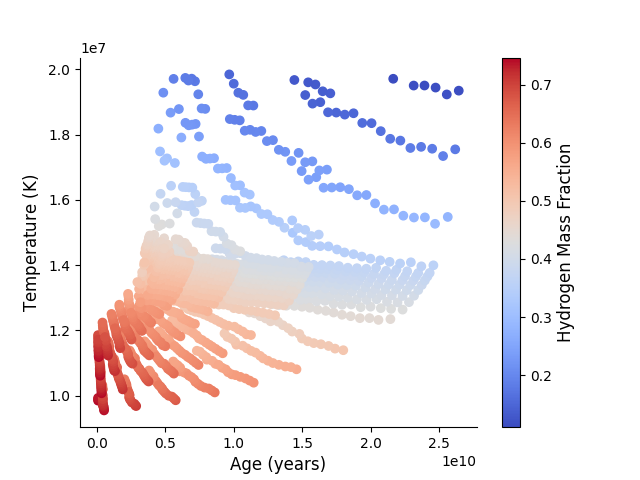

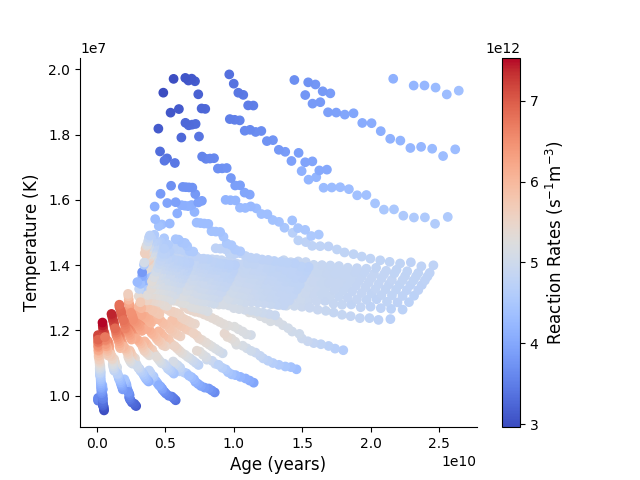

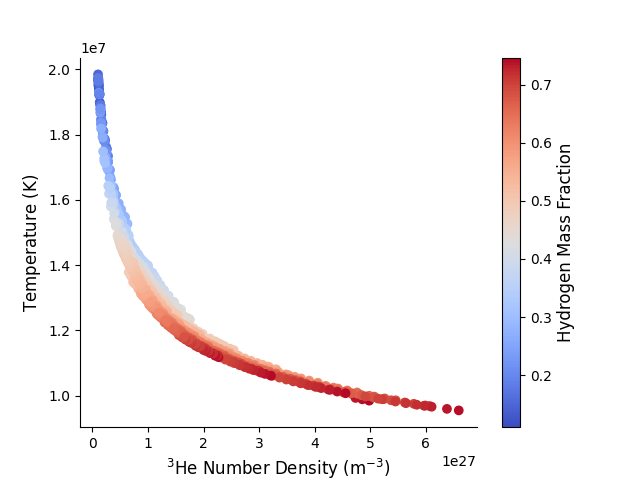

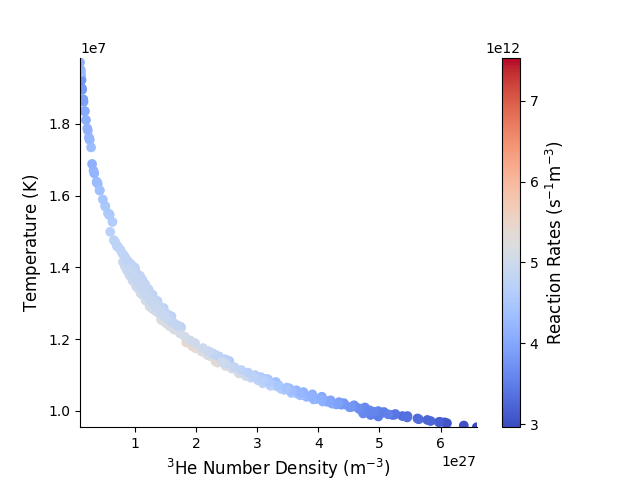

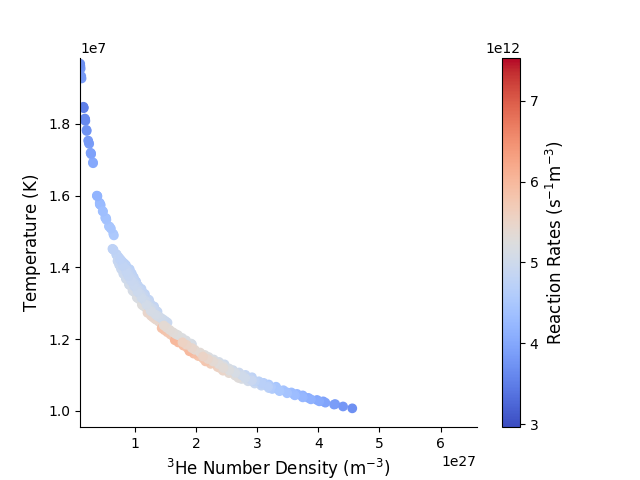

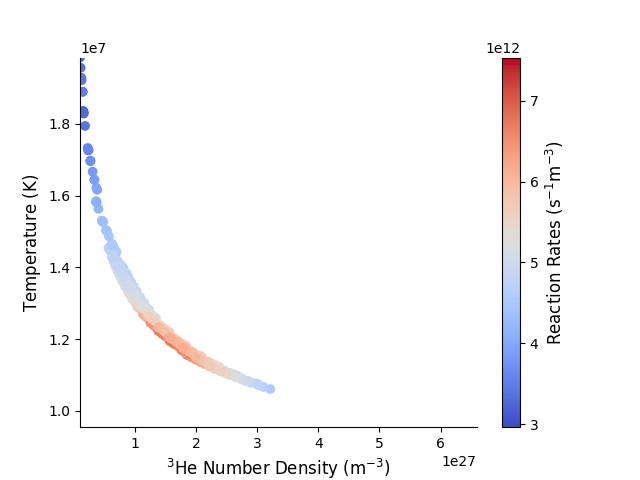

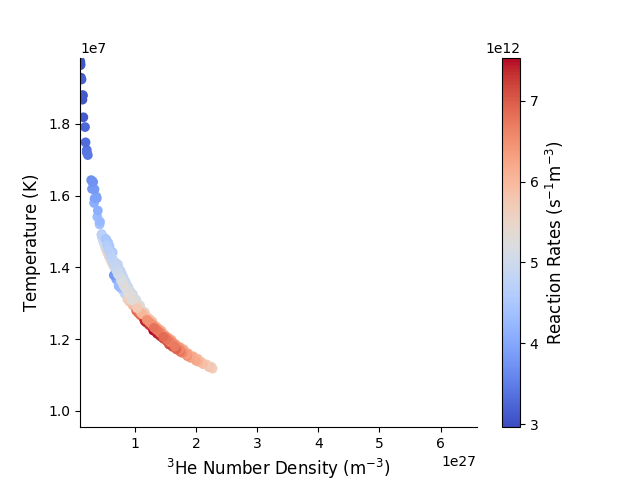

In [186]:
# Aux graphs - Age vs. Temp with H as color + reaction as color
# Aux graphs - density vs temp, with H as color
# Aux graphs - mass vs reaction rates

def graph(x, y, save_to, label_x, label_y, z=None, z_label=None, df=data, parent=None):
    fig = plt.figure()
    ax = fig.add_subplot()

    x_col = x
    y_col = y
    z_col = z

    # Generate random data
    x = (df[x])
    y = (df[y])
    # z = (data['reaction_rates_per_unit_volume'])

    if z:
        z = df[z]
        if parent is not None:
            scatter = ax.scatter(x, y, marker='o', c=z, cmap='coolwarm', vmin=parent[z_col].min(), vmax=parent[z_col].max())
        else:
            scatter = ax.scatter(x, y, marker='o', c=z, cmap='coolwarm')
        cbar = plt.colorbar(scatter)
        cbar.set_label(z_label, fontsize=12)

    else:
        ax.scatter(x, y, marker='o')

    ax.set_xlabel(label_x, size=12)
    ax.set_ylabel(label_y, size=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if parent is not None:
        ax.set_xlim(parent[x_col].min(), parent[x_col].max())
        ax.set_ylim(parent[y_col].min(), parent[y_col].max())

    fig.savefig(f'./figs/{save_to}.pdf')  # vector for LaTeX
    plt.show()


graph('age', 'core_temperature', 'age_vs_temp_zH', 'Age (years)', r'Temperature ($\mathrm{K}$)', z='H',
      z_label='Hydrogen Mass Fraction')
graph('age', 'core_temperature', 'age_vs_temp_zReaction', 'Age (years)', r'Temperature ($\mathrm{K}$)',
      z='reaction_rates_per_unit_volume', z_label=r'Reaction Rates ($\mathrm{s}^{-1}\mathrm{m}^{-3}$)')
graph('he3_number_density', 'core_temperature', 'density_vs_temp_zH', r'${}^3$He Number Density ($\mathrm{m}^{-3}$)',
      r'Temperature ($\mathrm{K}$)', z='H', z_label='Hydrogen Mass Fraction')

for mass in data['mass'].unique():
    slice = data[data['mass'] == mass]
    graph('he3_number_density', 'core_temperature', f'density_vs_temp_zReactions_m_{mass:.1f}'.replace('.', '_'),
          r'${}^3$He Number Density ($\mathrm{m}^{-3}$)', r'Temperature ($\mathrm{K}$)', z='reaction_rates_per_unit_volume',
          z_label=r'Reaction Rates ($\mathrm{s}^{-1}\mathrm{m}^{-3}$)', df=slice, parent=data)

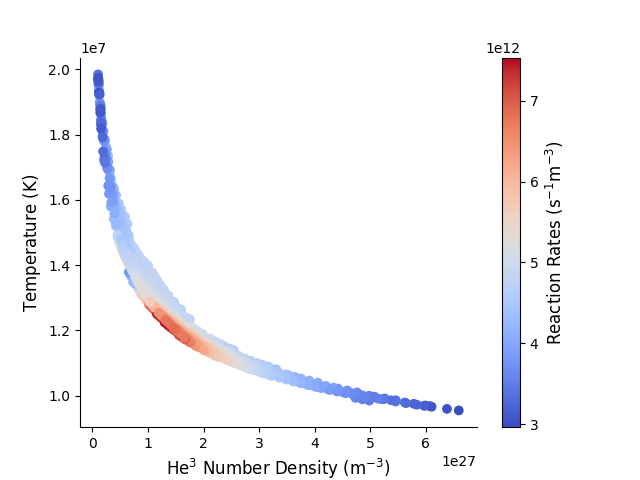

In [187]:
fig = plt.figure()
ax = fig.add_subplot()

# Generate random data
x = (data['he3_number_density'])
y = (data['core_temperature'])
z = (data['reaction_rates_per_unit_volume'])
# z = data['H']

scatter = ax.scatter(x, y, marker='o', c=z, cmap='coolwarm')
# legend = ax.legend(*scatter.legend_elements(), title="Mass")
# ax.add_artist(legend)

cbar = plt.colorbar(scatter)
cbar.set_label(r'Reaction Rates ($\mathrm{s}^{-1}\mathrm{m}^{-3}$)', fontsize=12)

ax.set_xlabel(r'He${}^3$ Number Density ($\mathrm{m}^{-3}$)', size=12)
ax.set_ylabel(r'Temperature ($\mathrm{K}$)', size=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.savefig('./figs/raw_data.pdf')  # vector for LaTeX
plt.show()

In [134]:
### Let's try a multi-variate regression
import pandas as pd
import statsmodels.api as sm

X = data[['he3_number_density', 'core_temperature']].copy()

X['he3_number_density'] = (data['he3_number_density']) / 1e27
X['core_temperature'] = (data['core_temperature']) / 1e6

X['he3_number_density^2'] = (X['he3_number_density']) ** 2
temp = (data['reaction_rates_per_unit_volume']) / 1e12

X['core_temperature^2'] = X['core_temperature'] ** 2
X['core_temperature^3'] = X['core_temperature'] ** 3

X = pd.concat([
    X['he3_number_density'],
    X['he3_number_density^2'],
    X['core_temperature'],
    X['core_temperature^2'],
    X['core_temperature^3']
], axis=1)

# X = pd.concat([X['he3_number_density'], X['core_temperature']], axis=1)

X = sm.add_constant(X)

model = sm.OLS(temp, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                  
==========================================================================================
Dep. Variable:     reaction_rates_per_unit_volume   R-squared:                       0.825
Model:                                        OLS   Adj. R-squared:                  0.824
Method:                             Least Squares   F-statistic:                     1219.
Date:                            Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                                    13:59:30   Log-Likelihood:                -308.85
No. Observations:                            1300   AIC:                             629.7
Df Residuals:                                1294   BIC:                             660.7
Df Model:                                       5                                         
Covariance Type:                        nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   66.9900      3.974     16.857      0.000      59.194      74.786
he3_number_density      -3.0883      0.097    -31.691      0.000      -3.279      -2.897
he3_number_density^2     0.1521      0.010     15.260      0.000       0.133       0.172
core_temperature        -8.1574      0.752    -10.854      0.000      -9.632      -6.683
core_temperature^2       0.3408      0.048      7.062      0.000       0.246       0.435
core_temperature^3      -0.0045      0.001     -4.356      0.000      -0.007      -0.002
==============================================================================
Omnibus:                      149.994   Durbin-Watson:                   0.621
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              668.630
Skew:                           0.456   Prob(JB):                    6.44e-146
Kurtosis:                       6.393   Cond. No.                     1.31e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.31e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [135]:
X['interaction'] = X['he3_number_density'] * X['core_temperature']

model_interaction = sm.OLS(temp, X).fit()
model_interaction.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                  
==========================================================================================
Dep. Variable:     reaction_rates_per_unit_volume   R-squared:                       0.872
Model:                                        OLS   Adj. R-squared:                  0.872
Method:                             Least Squares   F-statistic:                     1472.
Date:                            Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                                    13:59:32   Log-Likelihood:                -103.70
No. Observations:                            1300   AIC:                             221.4
Df Residuals:                                1293   BIC:                             257.6
Df Model:                                       6                                         
Covariance Type:                        nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  225.5659      7.996     28.210      0.000     209.879     241.252
he3_number_density     -19.3144      0.745    -25.911      0.000     -20.777     -17.852
he3_number_density^2     0.6767      0.025     26.621      0.000       0.627       0.727
core_temperature       -36.9651      1.464    -25.258      0.000     -39.836     -34.094
core_temperature^2       2.0631      0.089     23.238      0.000       1.889       2.237
core_temperature^3      -0.0386      0.002    -21.558      0.000      -0.042      -0.035
interaction              1.1863      0.054     21.905      0.000       1.080       1.293
==============================================================================
Omnibus:                      164.561   Durbin-Watson:                   0.793
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1047.588
Skew:                           0.387   Prob(JB):                    3.30e-228
Kurtosis:                       7.329   Cond. No.                     3.09e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.09e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [144]:
X

,const,he3_number_density,he3_number_density^2,core_temperature,core_temperature^2,core_temperature^3,interaction
16,1.0,4.980922,24.809579,9.843674,96.897913,953.831441,49.030567
17,1.0,6.593011,43.467797,9.544898,91.105073,869.588607,62.929618
18,1.0,6.063896,36.770833,9.679620,93.695052,906.932541,58.696210
19,1.0,5.458668,29.797060,9.855994,97.140627,957.417483,53.800605
20,1.0,4.762359,22.680067,10.095930,101.927795,1029.055848,48.080445
...,...,...,...,...,...,...,...
29,1.0,0.613668,0.376589,14.259932,203.345667,2899.695438,8.750871
30,1.0,0.596239,0.355501,14.344854,205.774829,2951.809817,8.552964
31,1.0,0.559880,0.313465,14.506678,210.443692,3052.838778,8.121995
32,1.0,0.427256,0.182548,15.272229,233.240964,3562.109296,6.525150


In [177]:
# Fit model with structural parameters

X_2 = X.copy()
X_2['age'] = data['age']
X_2['mass'] = data['mass']
X_2['H'] = data['H']

full_model = sm.OLS(temp, X_2).fit()
full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                  
==========================================================================================
Dep. Variable:     reaction_rates_per_unit_volume   R-squared:                       0.912
Model:                                        OLS   Adj. R-squared:                  0.911
Method:                             Least Squares   F-statistic:                     1478.
Date:                            Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                                    14:30:48   Log-Likelihood:                 135.10
No. Observations:                            1300   AIC:                            -250.2
Df Residuals:                                1290   BIC:                            -198.5
Df Model:                                       9                                         
Covariance Type:                        nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  160.2908      7.669     20.902      0.000     145.246     175.336
he3_number_density     -11.7334      0.778    -15.088      0.000     -13.259     -10.208
he3_number_density^2     0.4993      0.023     22.045      0.000       0.455       0.544
core_temperature       -25.4331      1.354    -18.790      0.000     -28.088     -22.778
core_temperature^2       1.3879      0.081     17.205      0.000       1.230       1.546
core_temperature^3      -0.0252      0.002    -15.557      0.000      -0.028      -0.022
interaction              0.5305      0.067      7.953      0.000       0.400       0.661
age                    4.73e-11   3.95e-12     11.976      0.000    3.96e-11    5.51e-11
mass                    -4.1768      0.246    -16.976      0.000      -4.659      -3.694
H                        9.6002      0.581     16.536      0.000       8.461      10.739
==============================================================================
Omnibus:                      171.049   Durbin-Watson:                   0.732
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1646.990
Skew:                           0.211   Prob(JB):                         0.00
Kurtosis:                       8.498   Cond. No.                     1.30e+13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.3e+13. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

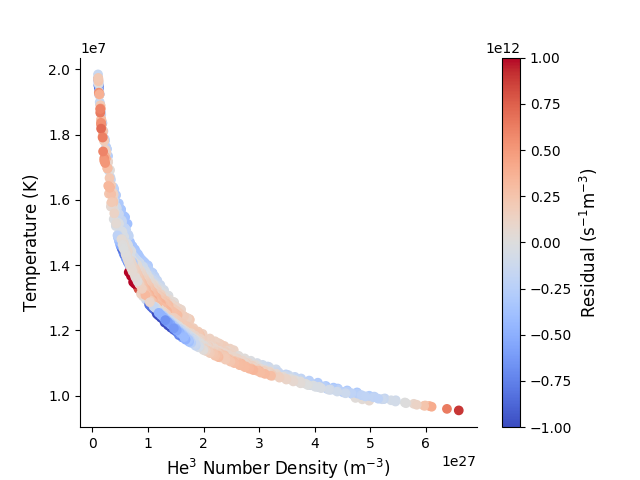

In [188]:
# Residuals

x_name = 'he3_number_density'
y_name = 'core_temperature'
Z = model_interaction.predict(X)

fig = plt.figure()
ax = fig.add_subplot()
scatter = ax.scatter(X[x_name] * 1e27, X[y_name] * 1e6, c=(Z - temp) * 1e12, cmap='coolwarm', vmin=-1e12, vmax=1e12)

ax.set_xlabel(r'He${}^3$ Number Density ($\mathrm{m}^{-3}$)', size=12)
ax.set_ylabel(r'Temperature ($\mathrm{K}$)', size=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

cbar = plt.colorbar(scatter)
cbar.set_label(r'Residual ($\mathrm{s}^{-1}\mathrm{m}^{-3}$)', fontsize=12)

fig.savefig('./figs/residuals.pdf')  # vector for LaTeX
plt.show()

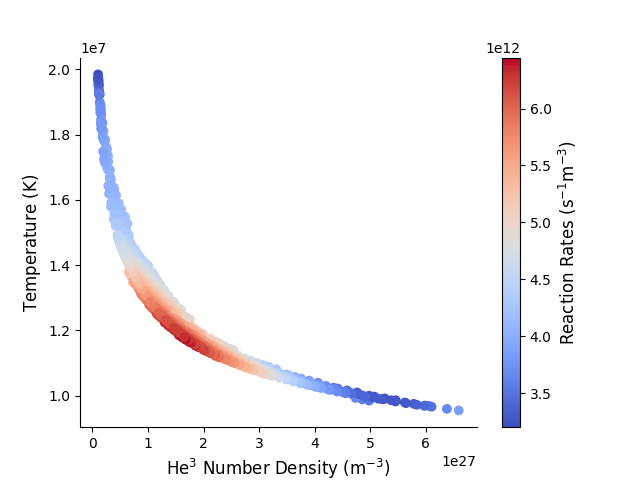

In [189]:
# Predictions

x_name = 'he3_number_density'
y_name = 'core_temperature'
Z = model_interaction.predict(X)

fig = plt.figure()
ax = fig.add_subplot()
scatter = ax.scatter(X[x_name] * 1e27, X[y_name] * 1e6, c=Z * 1e12, cmap='coolwarm')

ax.set_xlabel(r'He${}^3$ Number Density ($\mathrm{m}^{-3}$)', size=12)
ax.set_ylabel(r'Temperature ($\mathrm{K}$)', size=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

cbar = plt.colorbar(scatter)
cbar.set_label(r'Reaction Rates ($\mathrm{s}^{-1}\mathrm{m}^{-3}$)', fontsize=12)

fig.savefig('./figs/predictions.pdf')  # vector for LaTeX
plt.show()

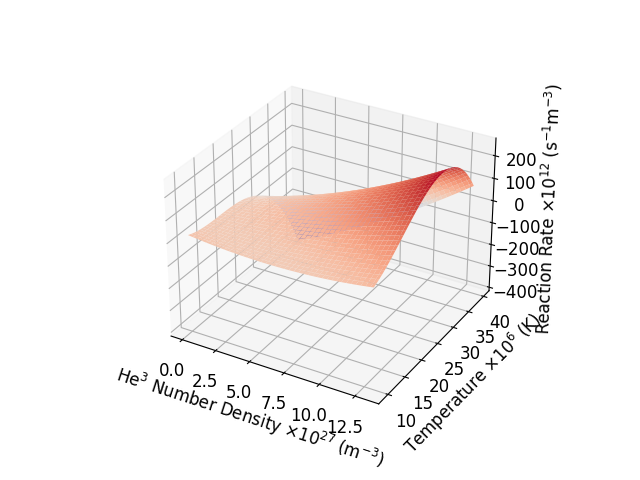

In [193]:
# Make surface plot
import statsmodels.api as sm

n_pts = 120
x_name = 'he3_number_density'
y_name = 'core_temperature'
x = np.linspace(X[x_name].min(), X[x_name].max() * 2, n_pts)
y = np.linspace(X[y_name].min(), X[y_name].max() * 2, n_pts)

Xg, Yg = np.meshgrid(x, y)

grid = pd.DataFrame({
    x_name: Xg.ravel(),
    y_name: Yg.ravel(),
})
grid['he3_number_density^2'] = grid[x_name] ** 2
grid['core_temperature^2'] = grid[y_name] ** 2
grid['core_temperature^3'] = grid[y_name] ** 3
grid['interaction'] = grid[x_name] * grid[y_name]

X_grid = sm.add_constant(grid[['he3_number_density', 'he3_number_density^2', 'core_temperature', 'core_temperature^2', 'core_temperature^3', 'interaction']])
Z = model_interaction.predict(X_grid).values.reshape(Xg.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Xg, Yg, Z, linewidth=0, antialiased=True, cmap='coolwarm')
ax.set_xlabel(r'He${}^3$ Number Density $\times10^{27}$ ($\mathrm{m}^{-3}$)', size=12)
ax.set_ylabel(r'Temperature $\times10^{6}$ ($\mathrm{K}$)', size=12)
ax.set_zlabel(r'Reaction Rate $\times10^{12}$ ($\mathrm{s}^{-1}\mathrm{m}^{-3}$)', size=12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=12)
plt.show()

In [ ]:
plt.close()

In [89]:
col = 'reaction_rates_per_unit_volume'
print(data[col].mean())
print(data[col].median())
print(data[col].std())

4958417032786.238
4902994103270.376
733656325307.6707
